# Run the standalone model

In [1]:
# Imports
import simpy
import numpy as np
from numpy.random import default_rng
from scipy.stats import expon
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class Security(object):
    def __init__(self, env, num_passport_reviewerss, num_pre_screening_helpers,
                 num_human_xray_reviewerss, num_bag_xray_reviewers, rg):
        # Simulation environment
        self.env = env
        self.rg = rg
        
        # Create list to hold timestamps dictionaries (one per traveler)
        self.timestamps_list = []
        # Create lists to hold occupancy tuples (time, occ)
        self.postxray_occupancy_list = [(0.0, 0.0)]
        self.xray_occupancy_list = [(0.0, 0.0)]
        self.bag_xray_occupancy_list = [(0.0, 0.0)]
        
        # Create resources
        self.passport_reviewer = simpy.Resource(env, num_passport_reviewerss)
        self.pre_screening_helper = simpy.Resource(env, num_pre_screening_helpers)
        self.human_xray_reviewer = simpy.Resource(env, num_human_xray_reviewerss)
        self.bag_xray_reviewer = simpy.Resource(env, num_bag_xray_reviewers)

    # Create process methods
    def passport_check(self, traveler):
        yield self.env.timeout(self.rg.normal(1.0, 0.2))

    def item_loading(self, traveler):
        yield self.env.timeout(self.rg.exponential(0.5))

    def human_xray_scan(self, traveler):
        yield self.env.timeout(self.rg.exponential(0.5))
        
    def bag_xray_scan(self, traveler):
        yield self.env.timeout(self.rg.exponential(0.5))

    # If additional screening is required, that will take more time
    def additional_screening(self, traveler):
        yield self.env.timeout(self.rg.normal(5.0, 1.0))
    
    # Some travelers take longer to leave than others after they have been screened
    # They will take at least half a minute, which is configured elsewhere
    def get_items_and_leave(self, traveler):
        yield self.env.timeout(self.rg.exponential(0.5))

In [3]:
def get_screened(env, traveler, security, pct_additional_screening, rg):
    # traveler arrives to security - note the arrival time
    arrival_ts = env.now

    # Request a passport reviewer for boarding pass/passport check
    # By using request() in a context manager, we'll automatically release the resource when done
    with security.passport_reviewer.request() as request:
        yield request
        # Now that we have a passport reviewer, check the boarding pass/passport. Note time.
        got_passport_reviewer_ts = env.now
        yield env.process(security.passport_check(traveler))
        release_passport_reviewer_ts = env.now

    # Request staff to help with pre-screening
    with security.pre_screening_helper.request() as request:
        yield request
        got_prescreen_help_ts = env.now
        yield env.process(security.item_loading(traveler))
        release_prescreen_help_ts = env.now

    # Initialize parallel timestamps (local variables get a NameError)
    got_xray_reviewer_ts = pd.NA
    release_xray_reviewer_ts = pd.NA
    got_add_xray_reviewer_ts = pd.NA
    release_add_xray_reviewer_ts = pd.NA
    got_bag_xray_reviewer_ts = pd.NA
    release_bag_xray_reviewer_ts = pd.NA
    got_add_bag_xray_reviewer_ts = pd.NA
    release_add_bag_xray_reviewer_ts = pd.NA
        
    # Request security staff to xray the traveler
    def human_branch():
        # Identify nonlocal variables
        nonlocal got_xray_reviewer_ts, release_xray_reviewer_ts, got_add_xray_reviewer_ts, release_add_xray_reviewer_ts
        
        with security.human_xray_reviewer.request() as request:
            yield request
            got_xray_reviewer_ts = env.now
            # Update xray occupancy - increment by 1
            prev_occ = security.xray_occupancy_list[-1][1]
            new_occ = (env.now, prev_occ + 1)
            security.xray_occupancy_list.append(new_occ)
            yield env.process(security.human_xray_scan(traveler))
            release_xray_reviewer_ts = env.now
            # Update xray occupancy - decrement by 1 - more compact code
            security.xray_occupancy_list.append((env.now, security.xray_occupancy_list[-1][1] - 1))
            
            # Update postxray occupancy - increment by 1
            security.postxray_occupancy_list.append((env.now, security.postxray_occupancy_list[-1][1] + 1))

        # Request human xray reviewer if additional screening is required
        if rg.random() < pct_additional_screening:
            with security.human_xray_reviewer.request() as request:
                yield request
                got_add_xray_reviewer_ts = env.now
                yield env.process(security.additional_screening(traveler))
                release_add_xray_reviewer_ts = env.now
        else:
            got_add_xray_reviewer_ts = pd.NA
            release_add_xray_reviewer_ts = pd.NA

    # Request security staff to xray the bag
    def bag_branch():
        # Identify nonlocal variables
        nonlocal got_bag_xray_reviewer_ts, release_bag_xray_reviewer_ts, got_add_bag_xray_reviewer_ts, release_add_bag_xray_reviewer_ts
        
        with security.bag_xray_reviewer.request() as request:
            yield request
            got_bag_xray_reviewer_ts = env.now
            # Update xray occupancy - increment by 1
            prev_occ = security.bag_xray_occupancy_list[-1][1]
            new_occ = (env.now, prev_occ + 1)
            security.bag_xray_occupancy_list.append(new_occ)
            yield env.process(security.bag_xray_scan(traveler))
            release_bag_xray_reviewer_ts = env.now
            # Update xray occupancy - decrement by 1 - more compact code
            security.bag_xray_occupancy_list.append((env.now, security.bag_xray_occupancy_list[-1][1] - 1))

        # Request bag xray reviewer if additional screening is required
        if rg.random() < pct_additional_screening:
            with security.bag_xray_reviewer.request() as request:
                yield request
                got_add_bag_xray_reviewer_ts = env.now
                yield env.process(security.additional_screening(traveler))
                release_add_bag_xray_reviewer_ts = env.now
        else:
            got_add_xray_reviewer_ts = pd.NA
            release_add_bag_xray_reviewer_ts = pd.NA

    # Trigger both the human and bag branches simultaneously and wait for them to both finish
    p_human = env.process(human_branch())
    p_bag = env.process(bag_branch())
    yield p_human & p_bag

    # We can't leave until both the human and bag screenings have finished
    finish_times = [release_xray_reviewer_ts, release_bag_xray_reviewer_ts]
    # Account for additional screening if either occurred
    if not pd.isna(release_add_xray_reviewer_ts):
        finish_times.append(release_add_xray_reviewer_ts)
    if not pd.isna(release_add_bag_xray_reviewer_ts):
        finish_times.append(release_add_bag_xray_reviewer_ts)
    # Get the later time of the two
    last_screening_finish = max(finish_times)
        
    # Wait at least half a minute from time we finished getting screened
    post_screen_time = env.now - last_screening_finish
    if post_screen_time < 0.5:
        # Wait until at least half a minute
        yield env.timeout(0.5 - post_screen_time)
        # Wait random amount beyond half a minute
        yield env.process(security.get_items_and_leave(traveler))
        exit_system_ts = env.now
        
        # Update postxray occupancy - decrement by 1
        security.postxray_occupancy_list.append((env.now, security.postxray_occupancy_list[-1][1] - 1))
    
    exit_system_ts = env.now    
    #print(f"traveler {traveler} exited at time {env.now}")

    # Create dictionary of timestamps
    timestamps = {'traveler_id': traveler,
                  'arrival_ts': arrival_ts,
                  'got_passport_reviewer_ts': got_passport_reviewer_ts,
                  'release_passport_reviewer_ts': release_passport_reviewer_ts,
                  'got_prescreen_help_ts': got_prescreen_help_ts,
                  'release_prescreen_help_ts': release_prescreen_help_ts,
                  'got_xray_reviewer_ts': got_xray_reviewer_ts,
                  'release_xray_reviewer_ts': release_xray_reviewer_ts,
                  'got_bag_xray_reviewer_ts': got_bag_xray_reviewer_ts,
                  'release_bag_xray_reviewer_ts': release_bag_xray_reviewer_ts,
                  'got_add_xray_reviewer_ts': got_add_xray_reviewer_ts,
                  'release_add_xray_reviewer_ts': release_add_bag_xray_reviewer_ts,
                  'got_add_bag_xray_reviewer_ts': got_add_xray_reviewer_ts,
                  'release_add_bag_xray_reviewer_ts': release_add_bag_xray_reviewer_ts,
                  'last_screening_finish': last_screening_finish,
                  'exit_system_ts': exit_system_ts}
    
    security.timestamps_list.append(timestamps)

In [4]:
def run_security(env, security, mean_interarrival_time, pct_additional_screening, rg, 
               stoptime=simpy.core.Infinity, max_arrivals=simpy.core.Infinity):
      
    # Create a counter to keep track of number of travelers generated and to serve as unique traveler id
    traveler = 0

    # Loop for generating travelers
    while env.now < stoptime and traveler < max_arrivals:

        # Generate next interarrival time (this will be more complicated later)
        iat = rg.exponential(mean_interarrival_time)
        
        # This process will now yield to a 'timeout' event. This process will resume after iat time units.
        yield env.timeout(iat)

        # New traveler generated = update counter of travelers
        traveler += 1
        
        #print(f"traveler {traveler} created at time {env.now}")

        env.process(get_screened(env, traveler, security, pct_additional_screening, rg))

In [5]:
def main(parameters):
    # Get parameter values
    travelers_per_hour = parameters['travelers_per_hour']
    pct_additional_screening = parameters['pct_additional_screening']
    rg = parameters['rg']
    num_passport_reviewers = parameters['num_passport_reviewers']
    num_pre_screening_helper = parameters['num_pre_screening_helper']
    num_human_xray_reviewers = parameters['num_human_xray_reviewers']
    num_bag_xray_reviewers = parameters['num_bag_xray_reviewers']
    stoptime = parameters['stoptime']
    
    # Calculate traveler arrival rate
    mean_interarrival_time = 1.0 / (travelers_per_hour / 60.0)
    
    # Create a simulation environment
    env = simpy.Environment()
    # Create a security to simulate
    security = Security(env, num_passport_reviewers, num_pre_screening_helper,
                        num_human_xray_reviewers, num_bag_xray_reviewers, rg)
    
    # Register the run_security (generator) function
    env.process(run_security(env, security, mean_interarrival_time, pct_additional_screening, rg, stoptime=stoptime))
    # Actually run the simulation
    env.run()
    
    # The simulation is over now, let's create the output csv files from 
    # the dataframes created by running the simulation model.
    
    # Output log files 
    security_traveler_log_df = pd.DataFrame(security.timestamps_list)
    security_traveler_log_df.to_csv('./output/security_traveler_log_df.csv', index=False)
    
    xray_occupancy_df = pd.DataFrame(security.xray_occupancy_list, columns=['ts', 'occ'])
    xray_occupancy_df.to_csv('./output/xray_occupancy_df.csv', index=False)
    
    postxray_occupancy_df = pd.DataFrame(security.postxray_occupancy_list, columns=['ts', 'occ'])
    postxray_occupancy_df.to_csv('./output/postxray_occupancy_df.csv', index=False)
    
    # Note simulation end time
    end_time = env.now
    print(f"Simulation ended at time {end_time}")
    return (end_time)

In [22]:
# Define parameters
parameters = {
    # Traveler arrival rate
    'travelers_per_hour': 600,
    'pct_additional_screening': 0.05,
    # Create a random number generator
    'rg': default_rng(seed=2503),
    # Resource capacity levels
    'num_passport_reviewers': 10,
    'num_pre_screening_helper': 12,
    'num_human_xray_reviewers': 8,
    'num_bag_xray_reviewers': 8,
    # Hours of operation
    'stoptime': 600 # No more arrivals after this time
}

# Run the system!
security_end_time = main(parameters)

Simulation ended at time 619.0815595569998


# Analyze results

In [23]:
def compute_durations(timestamp_df):
    
    timestamp_df['wait_for_passport_viewer'] = timestamp_df.loc[:, 'got_passport_reviewer_ts'] - timestamp_df.loc[:, 'arrival_ts']
    timestamp_df['wait_for_prescreen_help'] = timestamp_df.loc[:, 'got_prescreen_help_ts'] - timestamp_df.loc[:, 'release_passport_reviewer_ts']
    timestamp_df['wait_for_human_xray'] = timestamp_df.loc[:, 'got_xray_reviewer_ts'] - timestamp_df.loc[:, 'release_prescreen_help_ts']
    timestamp_df['human_xray_time'] = timestamp_df.loc[:, 'release_xray_reviewer_ts'] - timestamp_df.loc[:, 'got_xray_reviewer_ts']
    timestamp_df['wait_for_bag_xray'] = timestamp_df.loc[:, 'got_bag_xray_reviewer_ts'] - timestamp_df.loc[:, 'release_prescreen_help_ts']
    timestamp_df['bag_xray_time'] = timestamp_df.loc[:, 'release_bag_xray_reviewer_ts'] - timestamp_df.loc[:, 'got_bag_xray_reviewer_ts']
    timestamp_df['wait_for_baggage'] = timestamp_df.loc[:, 'last_screening_finish'] - timestamp_df.loc[:, 'release_xray_reviewer_ts']
    timestamp_df['post_xray_time'] = timestamp_df.loc[:, 'exit_system_ts'] - timestamp_df.loc[:, 'last_screening_finish']
    timestamp_df['time_in_system'] = timestamp_df.loc[:, 'exit_system_ts'] - timestamp_df.loc[:, 'arrival_ts']
    
    return timestamp_df

security_traveler_log_df = pd.read_csv('./output/security_traveler_log_df.csv')
security_traveler_log_df = compute_durations(security_traveler_log_df)
security_traveler_log_df.loc[:, ['wait_for_passport_viewer', 'wait_for_prescreen_help',
                                 'wait_for_human_xray', 'wait_for_bag_xray',
                                 'wait_for_baggage', 'post_xray_time', 'time_in_system']].describe()

,wait_for_passport_viewer,wait_for_prescreen_help,wait_for_human_xray,wait_for_bag_xray,wait_for_baggage,post_xray_time,time_in_system
count,6099.000000,6.099000e+03,6099.000000,6099.000000,6099.000000,6099.000000,6099.000000
mean,8.498283,8.266180e-07,1.121529,0.678581,0.934304,0.999339,13.533734
std,3.359987,6.455564e-05,1.426605,0.805749,1.800942,0.505119,3.952382
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.500206,1.649404
25%,7.273663,0.000000e+00,0.000000,0.000000,0.000000,0.637879,11.654084
50%,9.102180,0.000000e+00,0.509304,0.373763,0.000000,0.845801,13.776944
75%,10.527770,0.000000e+00,1.783707,1.177161,0.974011,1.186380,16.141724
max,14.380282,5.041543e-03,6.500921,4.475998,13.138842,5.041805,31.505212


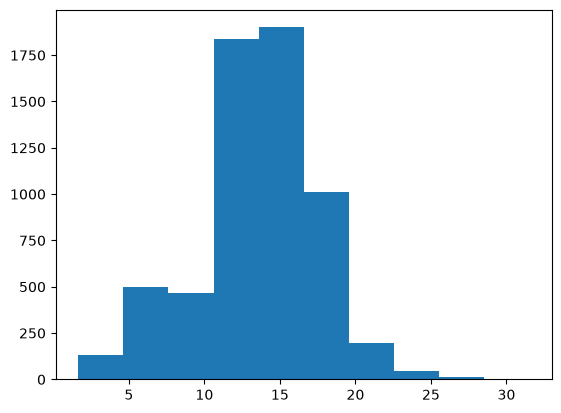

In [24]:
plt.hist(security_traveler_log_df['time_in_system']);

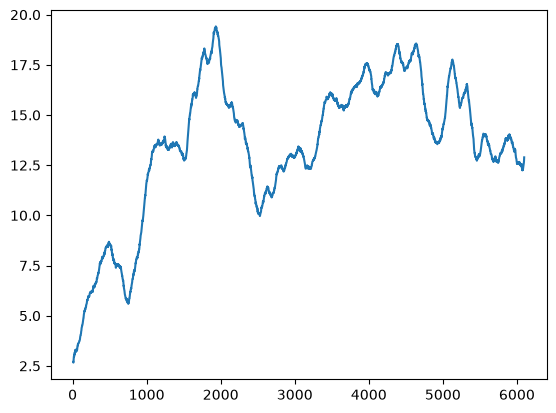

In [25]:
y = security_traveler_log_df['time_in_system'].rolling(100, 10).mean()
plt.plot(y)

In [26]:
xray_occupancy_df = pd.read_csv('./output/xray_occupancy_df.csv')

# Compute difference between ts[i] i and ts[i + 1] 
# (in pandas this corresponds to periods=-1 in diff() function)
xray_occupancy_df['occ_weight'] = -1 * xray_occupancy_df['ts'].diff(periods=-1)

# Need last occ_weight to compute weight for last row
last_weight = security_end_time - xray_occupancy_df.iloc[-1, 0]
xray_occupancy_df.fillna(last_weight, inplace=True)

,ts,occ,occ_weight
0,0.000000,0.0,1.118033
1,1.118033,1.0,0.123375
2,1.241409,2.0,0.053710
3,1.295119,3.0,0.109772
4,1.404891,2.0,0.121895
...,...,...,...
12194,611.186133,2.0,0.011456
12195,611.197589,3.0,0.092069
12196,611.289658,2.0,0.239612
12197,611.529271,1.0,1.717274


In [27]:
np.average(a=xray_occupancy_df['occ'], weights=xray_occupancy_df['occ_weight'])

np.float64(4.944677281223595)

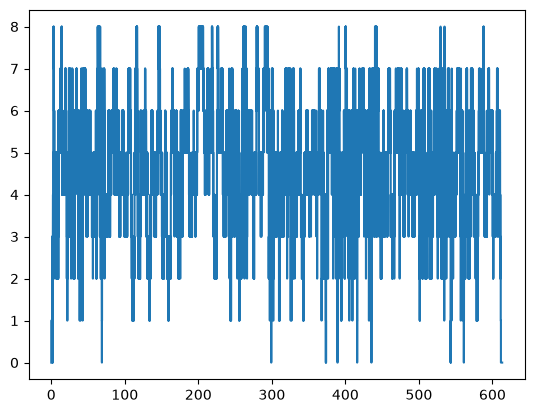

In [28]:
plt.step(xray_occupancy_df['ts'], xray_occupancy_df['occ'])

In [29]:
num_human_xray_viewers = 8
available_capacity = security_end_time * num_human_xray_viewers
available_capacity

used_capacity = security_traveler_log_df['human_xray_time'].sum()

xray_utilization = used_capacity / available_capacity

print(f"Xray utilization: {xray_utilization:0.3f}")

Xray utilization: 0.618


In [34]:
# Create a weighted stats object
from statsmodels.stats.weightstats import DescrStatsW

weighted_stats = DescrStatsW(xray_occupancy_df['occ'], weights=xray_occupancy_df['occ_weight'], ddof=0)


print(weighted_stats.mean)
print(weighted_stats.std)
occ_quantiles = weighted_stats.quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
print(occ_quantiles)

4.944677281223595
1.5166101152482885
p
0.00    0.0
0.01    0.0
0.05    2.0
0.25    4.0
0.50    5.0
0.75    6.0
0.95    7.0
0.99    8.0
dtype: float64


In [35]:
# Create a weighted stats object after throwing out first 100 points
weighted_stats_gt100 = DescrStatsW(xray_occupancy_df.iloc[100:, 1], weights=xray_occupancy_df.iloc[100:, 2], ddof=0)

print(weighted_stats_gt100.mean)
print(weighted_stats_gt100.std)
occ_quantiles = weighted_stats_gt100.quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
print(occ_quantiles)

4.962698513801479
1.4962594742558133
p
0.00    0.0
0.01    0.0
0.05    2.0
0.25    4.0
0.50    5.0
0.75    6.0
0.95    7.0
0.99    8.0
dtype: float64


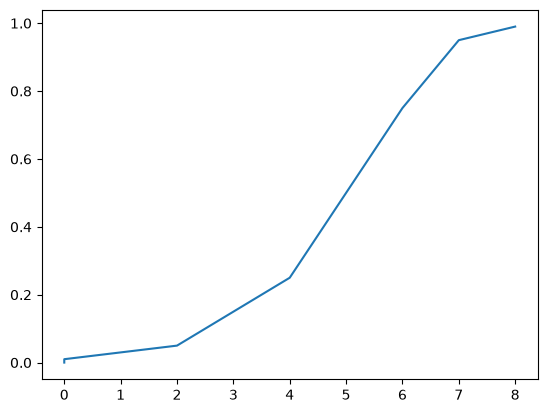

In [36]:
plt.plot(occ_quantiles, occ_quantiles.index);

In [37]:
# Calculate probablity density function (PDF) values
probs = -1 * pd.Series(occ_quantiles.index).diff(-1)
probs.fillna(1.0 - sum(probs[:-1]), inplace=True)

0    0.01
1    0.04
2    0.20
3    0.25
4    0.25
5    0.20
6    0.04
7    0.01
Name: p, dtype: float64

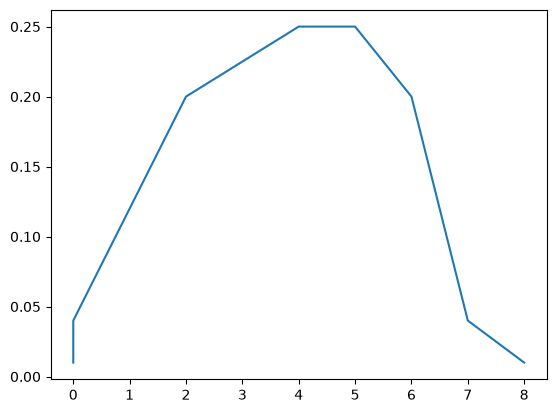

In [38]:
plt.plot(occ_quantiles, probs);